# Logistic Regression Visualizations

This notebook builds intuition for logistic regression in two settings:

1. **Two classes**, where the labels are written as `y = -1` and `y = +1`.
2. **Five classes**, where logistic regression uses a softmax layer to produce a probability distribution across classes.

The main ideas to watch for are:

- logistic regression learns a linear score for each class,
- the binary decision boundary is where the model is exactly uncertain,
- sigmoid and softmax convert scores into probabilities,
- cross entropy rewards high probability on the true class and penalizes confident mistakes.

In [1]:
from pathlib import Path
import os

cache_dir = Path(".matplotlib-cache")
cache_dir.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(cache_dir.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (7.5, 5.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

rng = np.random.default_rng(7)

## Part 1: Two Classes With Labels `y = -1` and `y = +1`

For binary logistic regression, the model learns one linear score:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

The sigmoid function turns that score into a probability:

$$
P(y=+1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

The decision boundary is the set of points where `z = 0`. At that boundary,
`P(y=+1 | x) = 0.5`, so the model is exactly split between the two classes.

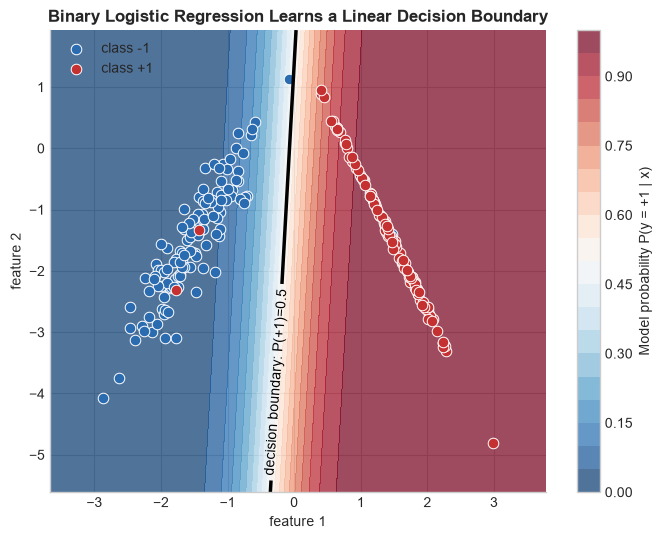

In [2]:
# Make a small two-feature dataset that is close to linearly separable.
X_binary, y_zero_one = make_classification(
    n_samples=240,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.45,
    flip_y=0.03,
    random_state=12,
)
y_pm = np.where(y_zero_one == 1, 1, -1)

binary_model = make_pipeline(
    StandardScaler(), #makes the input features normalized about the mean
    LogisticRegression(C=4.0, solver="lbfgs", random_state=12), # C is the inverse regularization strength, lbfgs is an optimization process for logistic regression
)
binary_model.fit(X_binary, y_pm)

# Create a grid over the feature space and evaluate P(y = +1) at each point.
x_min, x_max = X_binary[:, 0].min() - 0.8, X_binary[:, 0].max() + 0.8
y_min, y_max = X_binary[:, 1].min() - 0.8, X_binary[:, 1].max() + 0.8
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350),
)
grid = np.c_[xx.ravel(), yy.ravel()]
prob_plus = binary_model.predict_proba(grid)[:, list(binary_model.classes_).index(1)]
prob_plus = prob_plus.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
filled = ax.contourf(
    xx,
    yy,
    prob_plus,
    levels=np.linspace(0, 1, 21),
    cmap="RdBu_r",
    alpha=0.72,
)
boundary = ax.contour(xx, yy, prob_plus, levels=[0.5], colors="black", linewidths=2.5)
ax.clabel(boundary, fmt={0.5: "decision boundary: P(+1)=0.5"}, inline=True, fontsize=10)

ax.scatter(
    X_binary[y_pm == -1, 0],
    X_binary[y_pm == -1, 1],
    c="#2b6cb0",
    edgecolor="white",
    linewidth=0.7,
    s=58,
    label="class -1",
)
ax.scatter(
    X_binary[y_pm == 1, 0],
    X_binary[y_pm == 1, 1],
    c="#c53030",
    edgecolor="white",
    linewidth=0.7,
    s=58,
    label="class +1",
)
fig.colorbar(filled, ax=ax, label="Model probability P(y = +1 | x)")
ax.set_title("Binary Logistic Regression Learns a Linear Decision Boundary")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.legend(loc="upper left")
plt.show()

### Binary Cross Entropy With `y = -1` and `y = +1`

When labels are written as `-1` and `+1`, the binary cross entropy loss for one example can be written as (special case, binary selection):

$$
L(y, z) = \log(1 + e^{-yz})
$$

The product `yz` is called the **margin**:

- if `yz` is large and positive, the model is confident and correct,
- if `yz` is near zero, the model is uncertain,
- if `yz` is negative, the model predicts the wrong side of the boundary.

Mean binary cross entropy: 0.088


,y,score z,margin y*z,cross entropy,P(y=+1 | x)
43,-1,4.812,-4.812,4.820,0.992
10,1,-4.703,-4.703,4.712,0.009
92,1,-3.861,-3.861,3.882,0.021
224,-1,-0.200,0.200,0.598,0.450
30,1,1.253,1.253,0.251,0.778
155,1,1.253,1.253,0.251,0.778
108,1,1.409,1.409,0.219,0.804
66,-1,-1.607,1.607,0.183,0.167


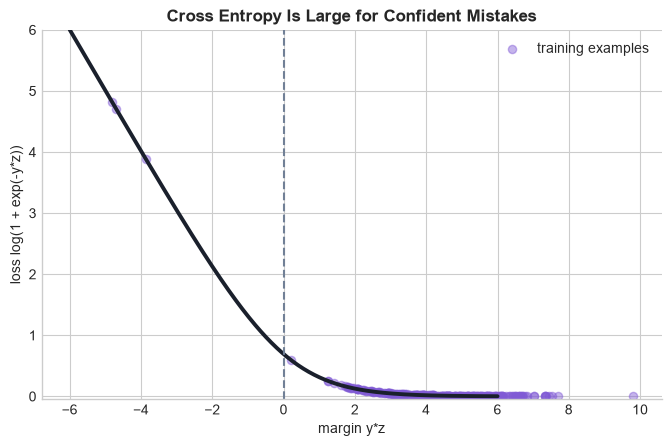

In [3]:
scores = binary_model.decision_function(X_binary) # score is the same as z = XW
margins = y_pm * scores
losses = np.logaddexp(0, -margins) #log add exponent = log(exp(argument 1) + exp(argument 2) + ...), noting that exp(0) = 1

summary = pd.DataFrame({
    "y": y_pm,
    "score z": scores,
    "margin y*z": margins,
    "cross entropy": losses,
    "P(y=+1 | x)": binary_model.predict_proba(X_binary)[:, list(binary_model.classes_).index(1)],
}).sort_values("cross entropy", ascending=False)

print(f"Mean binary cross entropy: {losses.mean():.3f}")
display(summary.head(8).round(3))

margin_grid = np.linspace(-6, 6, 400)
loss_grid = np.logaddexp(0, -margin_grid)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(margin_grid, loss_grid, color="#1a202c", linewidth=2.8)
ax.scatter(margins, losses, color="#805ad5", alpha=0.45, s=35, label="training examples")
ax.axvline(0, color="#718096", linestyle="--", linewidth=1.5)
ax.set_title("Cross Entropy Is Large for Confident Mistakes")
ax.set_xlabel("margin y*z")
ax.set_ylabel("loss log(1 + exp(-y*z))")
ax.set_ylim(-0.05, 6)
ax.legend()
plt.show()

## Part 2: Five Classes With Softmax Probabilities

For multiple classes, logistic regression learns one linear score per class:

$$
z_k = w_k^T x + b_k
$$

Notice that, here, the order of operations is slightly different. $z_k$ is M x 1, $w_k$ is N x M (which is later transposed) and $x$ is N x 1. A constant is added to every row through $b_k$

The softmax function converts the five scores into probabilities that add up to 1:

$$
P(y=k \mid x) =
\frac{e^{z_k}}{\sum_j e^{z_j}}
$$

For this example we will use scikit-learn's built-in handwritten digits dataset and keep only digits `0`, `1`, `2`, `3`, and `4`. This gives us a small, easy five-class classification problem with no data download.

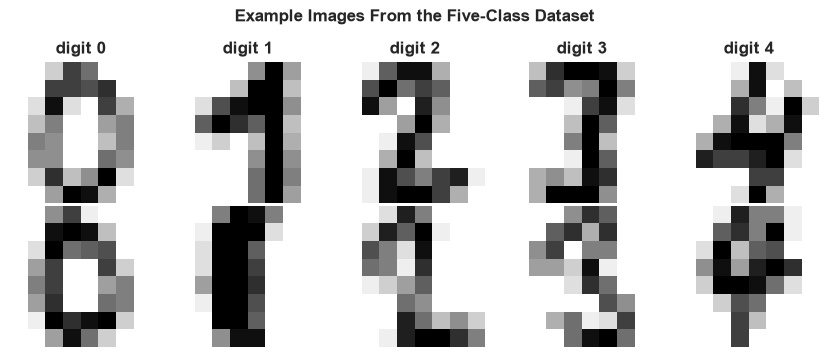

Training examples: 675
Testing examples:  226
Features per image: 64 pixel intensity values


In [4]:
digits = load_digits()
mask = digits.target < 5
X_digits = digits.data[mask]
y_digits = digits.target[mask]
images = digits.images[mask]

X_train, X_test, y_train, y_test, images_train, images_test = train_test_split(
    X_digits,
    y_digits,
    images,
    test_size=0.25,
    random_state=20,
    stratify=y_digits,
)

fig, axes = plt.subplots(2, 5, figsize=(8.5, 3.6))
for digit in range(5):
    digit_indices = np.flatnonzero(y_train == digit)[:2]
    for row, idx in enumerate(digit_indices):
        ax = axes[row, digit]
        ax.imshow(images_train[idx], cmap="gray_r")
        ax.set_title(f"digit {digit}" if row == 0 else "")
        ax.axis("off")
fig.suptitle("Example Images From the Five-Class Dataset", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Training examples: {X_train.shape[0]}")
print(f"Testing examples:  {X_test.shape[0]}")
print(f"Features per image: {X_train.shape[1]} pixel intensity values")

Test accuracy: 0.996
Test multiclass cross entropy / log loss: 0.024


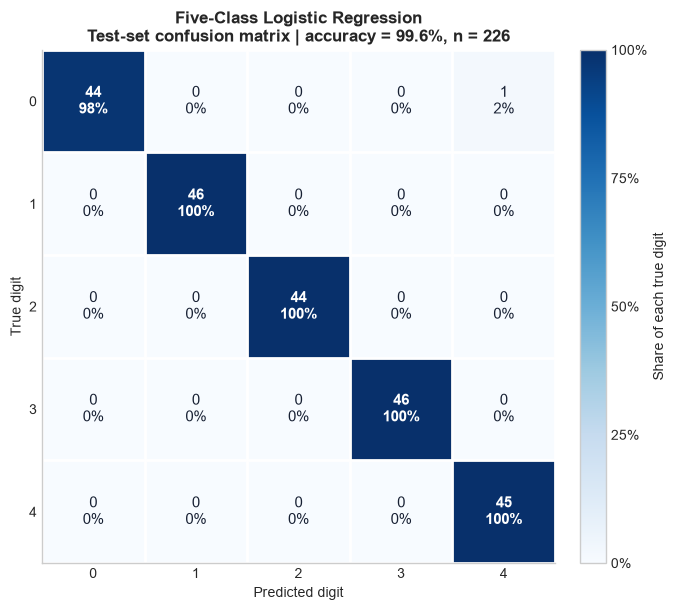

In [5]:
softmax_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000, solver="lbfgs", random_state=20),
)
softmax_model.fit(X_train, y_train)

y_pred = softmax_model.predict(X_test)
probabilities = softmax_model.predict_proba(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Test multiclass cross entropy / log loss: {log_loss(y_test, probabilities):.3f}")

classes = np.arange(5)
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_share = cm / cm.sum(axis=1, keepdims=True)
test_accuracy = accuracy_score(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
image = ax.imshow(cm_share, cmap="Blues", vmin=0, vmax=1)

for true_digit in classes:
    for predicted_digit in classes:
        share = cm_share[true_digit, predicted_digit]
        text_color = "white" if share > 0.50 else "#172033"
        ax.text(
            predicted_digit,
            true_digit,
            f"{cm[true_digit, predicted_digit]}\n{share:.0%}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=11,
            fontweight="bold" if true_digit == predicted_digit else "normal",
        )

ax.set(
    xticks=classes,
    yticks=classes,
    xlabel="Predicted digit",
    ylabel="True digit",
    title=(
        "Five-Class Logistic Regression\n"
        f"Test-set confusion matrix | accuracy = {test_accuracy:.1%}, n = {len(y_test)}"
    ),
)
ax.set_xticks(np.arange(-0.5, len(classes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(classes), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.grid(which="major", visible=False)

colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Share of each true digit")
colorbar.set_ticks([0, 0.25, 0.50, 0.75, 1.0])
colorbar.set_ticklabels(["0%", "25%", "50%", "75%", "100%"])

plt.tight_layout()
plt.show()

### Looking Directly at Softmax

The model first computes five raw scores, one per digit class. Softmax turns those scores into probabilities.

The multiclass cross entropy for one labeled example is:

$$
L = -\sum_k y_k \log(p_k)
$$

Because one-hot labels have a single `1`, this simplifies to:

$$
L = -\log(p_{\text{true class}})
$$

In [6]:
def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / exp_scores.sum(axis=1, keepdims=True)


logits = softmax_model.decision_function(X_test[:6])
manual_probs = softmax(logits)
model_probs = softmax_model.predict_proba(X_test[:6])

prob_table = pd.DataFrame(
    model_probs,
    columns=[f"P(digit={k})" for k in softmax_model.classes_],
)
prob_table.insert(0, "true digit", y_test[:6])
prob_table.insert(1, "predicted digit", y_pred[:6])
prob_table["probability sum"] = model_probs.sum(axis=1)
prob_table["cross entropy"] = -np.log(model_probs[np.arange(6), y_test[:6]])

print("Largest difference between manual softmax and model probabilities:")
print(np.abs(manual_probs - model_probs).max())
display(prob_table.round(4))

Largest difference between manual softmax and model probabilities:
0.0


,true digit,predicted digit,P(digit=0),P(digit=1),P(digit=2),P(digit=3),P(digit=4),probability sum,cross entropy
0,1,1,0.0000,0.9997,0.0001,0.0001,0.0001,1.0,0.0003
1,4,4,0.0000,0.0000,0.0000,0.0000,1.0000,1.0,0.0000
2,2,2,0.0000,0.0000,0.9999,0.0000,0.0000,1.0,0.0001
3,3,3,0.0000,0.0000,0.0001,0.9999,0.0000,1.0,0.0001
4,0,0,0.9991,0.0000,0.0000,0.0005,0.0003,1.0,0.0009
5,2,2,0.0000,0.0000,0.9998,0.0002,0.0000,1.0,0.0002


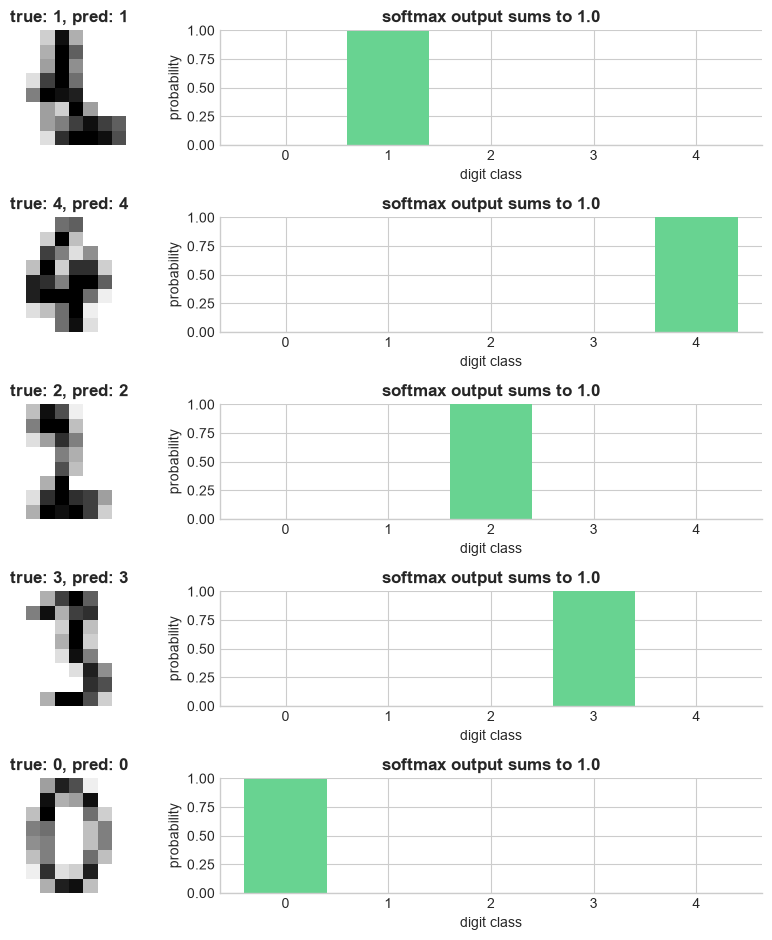

In [7]:
example_indices = np.array([0, 1, 2, 3, 4])
fig, axes = plt.subplots(len(example_indices), 2, figsize=(8.2, 9.5), gridspec_kw={"width_ratios": [1, 2.8]})

for row, idx in enumerate(example_indices):
    image_ax, bar_ax = axes[row]

    image_ax.imshow(images_test[idx], cmap="gray_r")
    image_ax.set_title(f"true: {y_test[idx]}, pred: {y_pred[idx]}")
    image_ax.axis("off")

    colors = ["#68d391" if k == y_test[idx] else "#63b3ed" for k in softmax_model.classes_]
    bar_ax.bar(softmax_model.classes_.astype(str), probabilities[idx], color=colors)
    bar_ax.set_ylim(0, 1)
    bar_ax.set_ylabel("probability")
    bar_ax.set_xlabel("digit class")
    bar_ax.set_title(f"softmax output sums to {probabilities[idx].sum():.1f}")

plt.tight_layout()
plt.show()

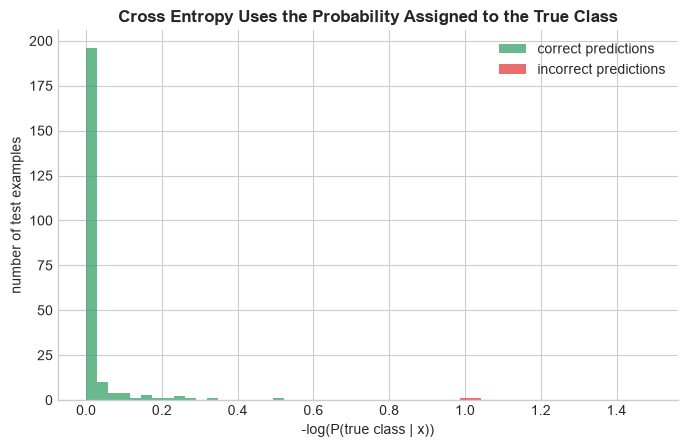

,true digit,predicted digit,P(true class),cross entropy
50,0,4,0.3724,0.9877
10,3,3,0.5939,0.5210
21,2,2,0.7081,0.3451
207,2,2,0.7681,0.2639
80,4,4,0.7848,0.2423
70,3,3,0.7922,0.2330
15,2,2,0.8128,0.2073
102,3,3,0.8324,0.1834
152,3,3,0.8448,0.1686
83,4,4,0.8472,0.1658


In [8]:
true_class_probability = probabilities[np.arange(len(y_test)), y_test]
per_example_loss = -np.log(true_class_probability)
correct = y_pred == y_test

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(
    per_example_loss[correct],
    bins=18,
    alpha=0.75,
    color="#38a169",
    label="correct predictions",
)
ax.hist(
    per_example_loss[~correct],
    bins=18,
    alpha=0.75,
    color="#e53e3e",
    label="incorrect predictions",
)
ax.set_title("Cross Entropy Uses the Probability Assigned to the True Class")
ax.set_xlabel("-log(P(true class | x))")
ax.set_ylabel("number of test examples")
ax.legend()
plt.show()

loss_table = pd.DataFrame({
    "true digit": y_test,
    "predicted digit": y_pred,
    "P(true class)": true_class_probability,
    "cross entropy": per_example_loss,
}).sort_values("cross entropy", ascending=False)

display(loss_table.head(10).round(4))

In [9]:
X = np.array([2.4, 3.3, -1, 1, 0, 0]).reshape(1,-1)
theta = np.array([[1, 4],[-1, 0],[0, 2],[3, -1],[0.5, 0.2],[1, 0.2]])
z = X @ theta
print("logit = ", z)
print("exponent of z =", np.exp(z))
y_pred = np.exp(z)/np.sum(np.exp(z))
print("prediction =", y_pred)

logit =  [[2.1 6.6]]
exponent of z = [[  8.16616991 735.09518924]]
prediction = [[0.01098694 0.98901306]]
